In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

In [ ]:
from google.colab import files

files.upload()

In [ ]:
results = model('yeah.jpg', show=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /content/yeah.jpg: 448x640 2 persons, 1 elephant, 210.7ms
Speed: 4.3ms preprocess, 210.7ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


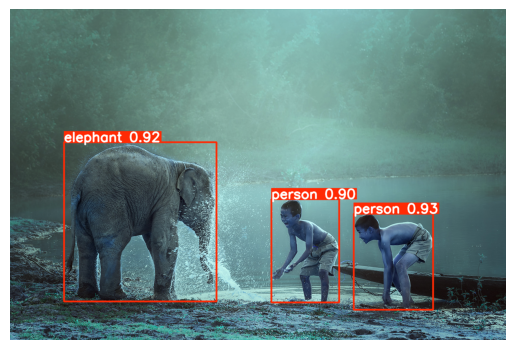

In [ ]:
import matplotlib.pyplot as plt

im_array = results[0].plot()
plt.imshow(im_array)
plt.axis('off')
plt.show()

In [ ]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode
import matplotlib.pyplot as plt

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Run YOLO detection on the captured image
  results = model(filename, show=False) # show=False to prevent cv2.imshow issues

  # Plot the results using matplotlib
  im_array = results[0].plot() # plot a BGR numpy array of predictions
  plt.imshow(im_array[..., ::-1]) # RGB conversion for matplotlib
  plt.axis('off')
  plt.show()

except Exception as err:
  # Errors will be thrown if the user does not have a webcam or denies access
  print(str(err))
  print('You may have denied permission to use the webcam, or your browser does not support it.')

<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [ ]:
import zipfile
import os

# Replace 'archive.zip' with the path to your zip file
zip_file_path = 'yay.zip'
# Replace './extracted_content' with the desired directory to extract content
extraction_dir = './dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_dir)
    print(f"Successfully extracted '{zip_file_path}' to '{extraction_dir}'")
except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully extracted 'yay.zip' to './dataset'


In [ ]:
import yaml

# Define the content for data.yaml based on the provided structure
data_yaml_content = {
    'path': '/content/dataset',  # Dataset root directory
    'train': 'images/train',     # Path to training images relative to 'path'
    'val': 'images/val',       # Path to validation images relative to 'path'
    'test': None,                # Optional: path to test images relative to 'path'

    # Number of classes
    'nc': 1,  # You need to update this with the actual number of classes in your dataset

    # Class names
    'names': ['your_class_name'], # You need to update this with your actual class names

    'roboflow': {
        'workspace': 'your-workspace',
        'project': 'your-project',
        'version': 1
    }
}

# Define the path where data.yaml will be saved
data_yaml_path = '/content/dataset/data.yaml'

# Write the content to data.yaml
with open(data_yaml_path, 'w') as file:
    yaml.dump(data_yaml_content, file, default_flow_style=False)

print(f"'{data_yaml_path}' has been created with the following content:")
with open(data_yaml_path, 'r') as file:
    print(file.read())

'/content/dataset/data.yaml' has been created with the following content:
names:
- your_class_name
nc: 1
path: /content/dataset
roboflow:
  project: your-project
  version: 1
  workspace: your-workspace
test: null
train: images/train
val: images/val



In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(data='/content/dataset/data.yaml', epochs=50, imgsz=640)

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c41427a4fb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
import pandas as pd

metrics = model.metrics

print(f"Precision: {metrics.box.p}")
print(f"Recall: {metrics.box.r}")
print(f"mAP@0.5: {metrics.box.map50}")
print(f"mAP@0.5:0.95: {metrics.box.map}")


Precision: [  0.0033333]
Recall: [          1]
mAP@0.5: 0.995
mAP@0.5:0.95: 0.5970000000000001


In [ ]:
import pandas as pd

val_results = model.val()

Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3472.0±1004.5 MB/s, size: 177.2 KB)
val: Scanning /content/dataset/labels/val.cache... 91 images, 0 backgrounds, 90 corrupt: 100% ━━━━━━━━━━━━ 91/91 42.4Mit/s 0.0s
val: /content/dataset/images/val/20250506_205726_mp4-0002_jpg.rf.1883aeaadec2056393879d99936da3c2.jpg: ignoring corrupt image/label: Label class 16 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/dataset/images/val/20250506_205726_mp4-0008_jpg.rf.548a3818df22f91dce2eaf6c0171f390.jpg: ignoring corrupt image/label: Label class 16 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/dataset/images/val/20250506_205726_mp4-0018_jpg.rf.b2aa14e0e0b05249012602a305956399.jpg: ignoring corrupt image/label: Label class 18 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/dataset/images/val/20250506_205726_mp4-0022_jpg.rf.2d52b773a80

In [ ]:
metrics = val_results

print(f"Precision: {metrics.box.p}")
print(f"Recall: {metrics.box.r}")
print(f"mAP@0.5: {metrics.box.map50}")
print(f"mAP@0.5:0.95: {metrics.box.map}")

Precision: [  0.0033333]
Recall: [          1]
mAP@0.5: 0.995
mAP@0.5:0.95: 0.5970000000000001
